In [4]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
from sklearn.manifold import TSNE

In [ ]:
#input: Full adata and SAM object alongside neuronal adata
#output: Anndata object with low quality clusters removed

In [51]:
cj_dat = sc.read_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/tot_dat_AC_ncbi_soupx_neuron_02272025.h5ad')

In [52]:
cj_dat

AnnData object with n_obs × n_vars = 39788 × 23671
    obs: 'n_counts', 'n_genes', 'key', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'leiden_clusters', 'eq_subclass_nounlabeled', 'region_label', 'neurotransmitter', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [53]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_neuron_02272025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [54]:
sam_cj.adata.obs['key']

AAACGAAAGGACTGGT    Run12_sample1
AAACGAACAAGAGATT    Run12_sample1
AAAGAACAGTATTGCC    Run12_sample1
AAAGAACCACTTGGCG    Run12_sample1
AAAGAACTCGGCCTTT    Run12_sample1
                        ...      
TTTGTTGTCATATGGC    Run17_sample4
TTTGTTGTCCAAACCA    Run17_sample4
TTTGTTGTCGCAGTCG    Run17_sample4
TTTGTTGTCTACTCAT    Run17_sample4
TTTGTTGTCTTTGCGC    Run17_sample4
Name: key, Length: 39788, dtype: category
Categories (13, object): ['Run12_sample1', 'Run12_sample2', 'Run12_sample3', 'Run12_sample5', ..., 'Run12_sample12', 'Run17_sample2', 'Run17_sample3', 'Run17_sample4']

In [55]:
#Manually set (choose a resolution that clusters the data well)
sam_cj.clustering(param = 1)

In [56]:
sam_cj.adata.obs['leiden_clusters'].nunique()

55

In [57]:
level = 'leiden_clusters'

In [18]:
Xtsne = TSNE(n_components=2, metric = 'cosine').fit_transform(sam_cj.adata.obsm['X_pca'])

/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/scratch/miniconda/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:827: FutureWarning: 'square_distances' has been introduced in 0.24 to help phase out legacy squaring behavior. The 'legacy' setting will be removed in 1.1 (renaming of 0.26), and the default setting will be changed to True. In 1.3, 'square_distances' will be removed altogether, and distances will be squared by default. Set 'square_distances'=True to silence this warning.
  FutureWarning,


In [68]:
sam_cj.adata.obsm['X_tsne'] = Xtsne

NameError: name 'Xtsne' is not defined

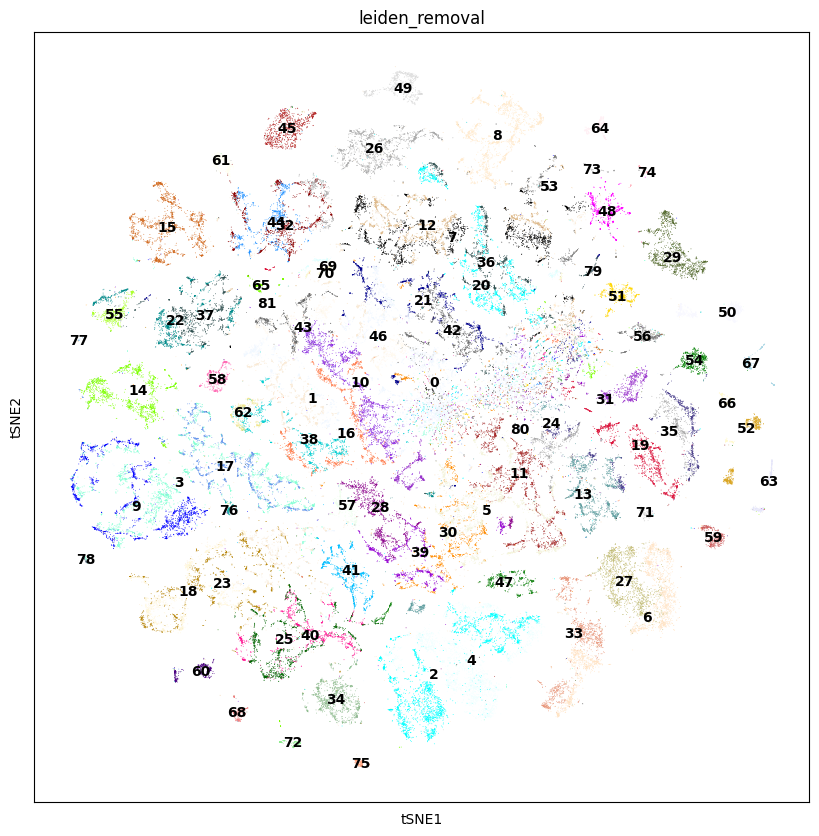

In [20]:
sns.reset_orig()
plt.rcParams['figure.figsize'] = 10,10
sc.pl.tsne(sam_cj.adata, color = 'leiden_removal', palette = list(matplotlib.colors.CSS4_COLORS), legend_loc='on data')

In [34]:
cj_dat.obs[level] = sam_cj.adata.obs[level]

In [ ]:
#look for marker genes
sc.pl.dotplot(cj_dat, ['SLC32A1','SLC17A6','SYT1','MBP'], groupby = 'leiden_clusters')

(0.0, 20000.0)

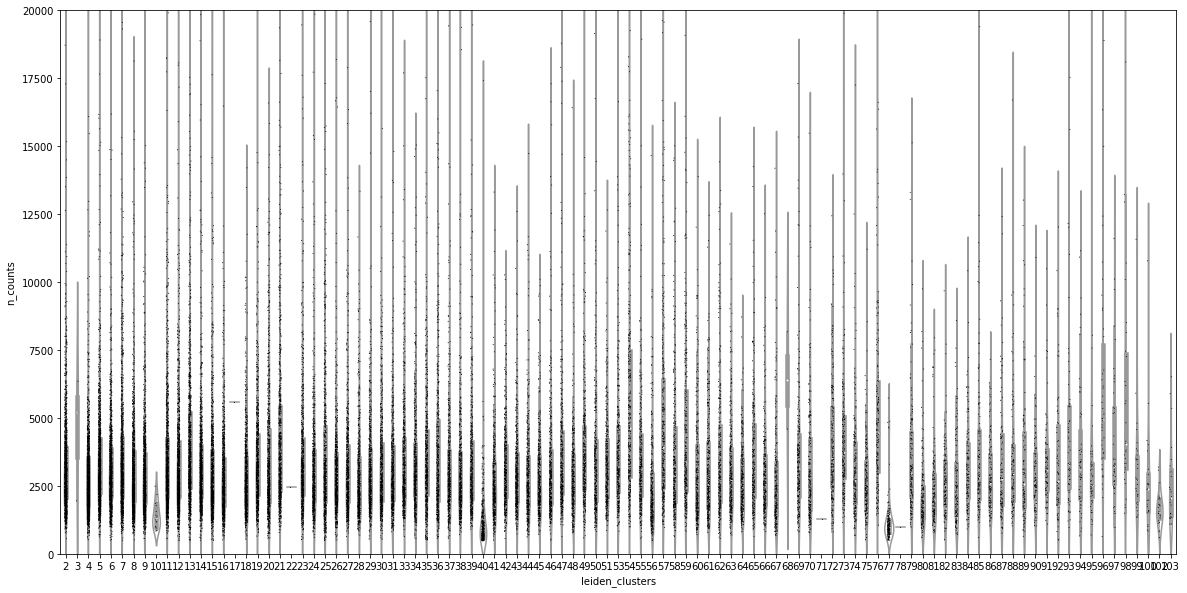

In [58]:
plt.rcParams['figure.figsize'] = 20,10
sns.violinplot(x = 'leiden_clusters', y = 'n_counts', data = cj_dat .obs, color = 'white')
sns.stripplot(x = 'leiden_clusters', y = 'n_counts', data = cj_dat.obs, color = 'black', size = 1)
plt.ylim(0,20000)

(0.0, 7500.0)

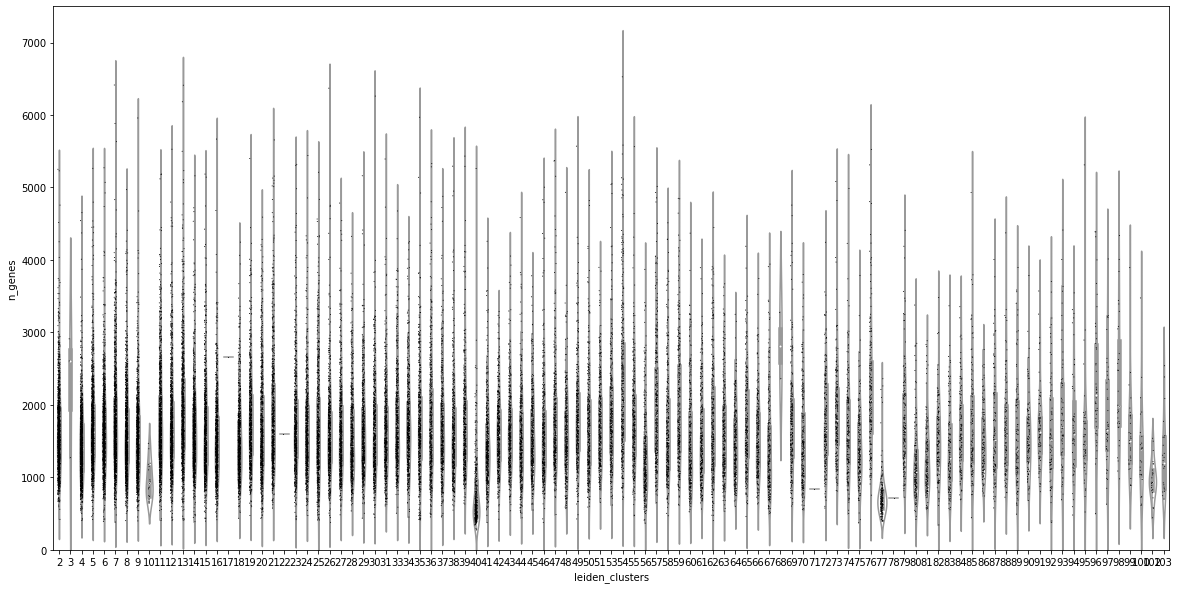

In [59]:
plt.rcParams['figure.figsize'] = 20,10
sns.violinplot(x = 'leiden_clusters', y = 'n_genes', data = cj_dat .obs, color = 'white')
sns.stripplot(x = 'leiden_clusters', y = 'n_genes', data = cj_dat.obs, color = 'black', size = 1)
plt.ylim(0,7500)

In [60]:
ncounts_dict = {}
for item in cj_dat.obs[level].unique():
    val = np.median(cj_dat[cj_dat.obs[level] == item].obs['n_counts'])
    ncounts_dict[item] = val

(array([ 3.,  2.,  1.,  1.,  5.,  7., 29., 25., 11.,  6.,  1.,  2.,  1.,
         1.,  1.,  1.,  0.,  1.,  0.,  1.]),
 array([ 816.   , 1094.325, 1372.65 , 1650.975, 1929.3  , 2207.625,
        2485.95 , 2764.275, 3042.6  , 3320.925, 3599.25 , 3877.575,
        4155.9  , 4434.225, 4712.55 , 4990.875, 5269.2  , 5547.525,
        5825.85 , 6104.175, 6382.5  ], dtype=float32),
 <BarContainer object of 20 artists>)

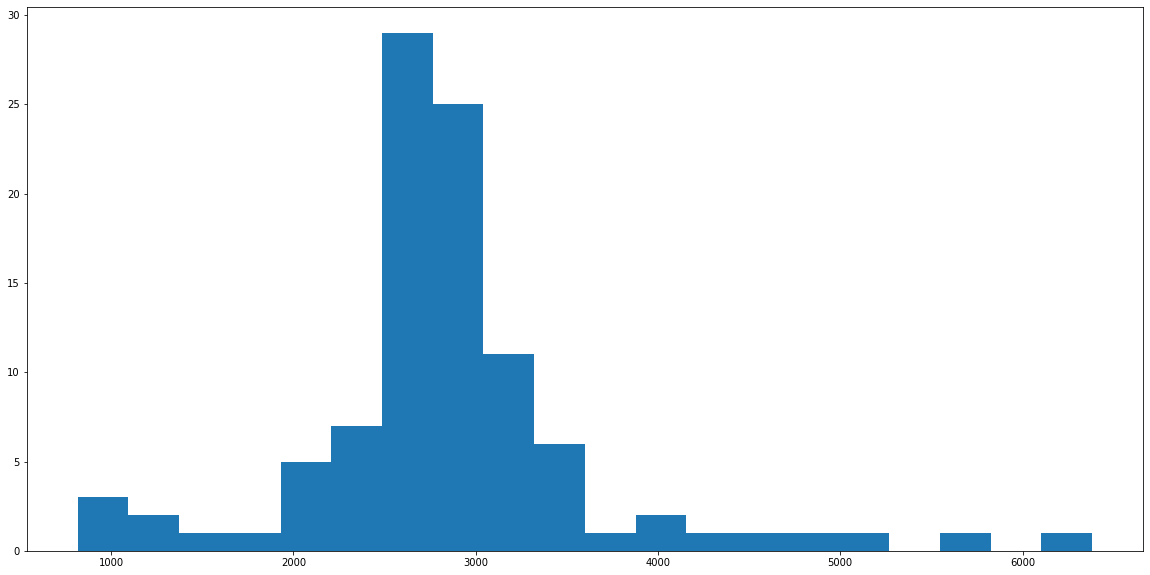

In [61]:
plt.hist(ncounts_dict.values(), bins = 20)

In [62]:
ncounts = list(ncounts_dict.values())
threshold = np.percentile(ncounts, 15)
threshold

2378.5

In [63]:
#Manually set based on the histogram
rct = set([i for i in ncounts_dict.keys() if ncounts_dict[i]> 10000] + [i for i in ncounts_dict.keys() if ncounts_dict[i]< threshold])

In [64]:
rct

{10, 28, 40, 41, 56, 67, 71, 77, 78, 80, 81, 83, 100, 102, 103}

In [55]:
from tqdm import tqdm

def marker_genes(adata,level,ct,frac = .1,lf = 1, alpha = .05):
    marker_dict = {}
    diff_dict = {}
    gene_dict = {gene: idx for idx, gene in enumerate(adata.var_names)}
    exp = adata.X.A
    for item in tqdm(ct):
        #get differentially expressed genes
        item = str(item)
        sc.tl.rank_genes_groups(adata, groupby=level, method='wilcoxon')
        diff_genes = sc.get.rank_genes_groups_df(adata, group = [item])
        diff_dict[item] = diff_genes

        #set thresholds to speed up the background calculation 
        sig_genes = diff_genes[(diff_genes['pvals_adj'] < alpha) & (diff_genes['logfoldchanges'] > lf)]
        group_mask = adata.obs[level] == item
        background_mask = ~group_mask

        #get background expression (fraction of background cells that express)
        bkgd_exp = []
        for gene in sig_genes['names']:
            detection = (exp[background_mask,gene_dict[gene]] > 0).sum() / background_mask.sum()
            bkgd_exp.append(detection)
        sig_genes['background_exp'] = bkgd_exp

        #set threshold on background expression 
        sig_genes = sig_genes[sig_genes['background_exp'] < frac]
        marker_dict[item] = sig_genes
    return(marker_dict, diff_dict)

In [56]:
marker_dict, diff_dict = marker_genes(sam_cj.adata,'leiden_clusters',[50,56], frac = .1, lf = .5)

  0%|                                                     | 0/2 [00:00<?, ?it/s]/scratch/miniconda/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/scratch/miniconda/lib/python3.7/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/scratch/miniconda/lib/python3.7/site-packages/scanpy/tools/_ra

In [162]:
#Put the cell clusters you want to remove here
cleaned_cells = set(dat[dat.obs['leiden_clusters_neuron'].isin([])].obs_names)

In [163]:
a = 0
for item in cleaned_cells:
    if item in dat.obs_names:
        a += 1

In [164]:
a

5188

In [165]:
cleaned_adata = dat[~dat.obs_names.isin(cleaned_cells)]

In [166]:
cleaned_adata

View of AnnData object with n_obs × n_vars = 61430 × 25503
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters_neuron'

In [189]:
cleaned_adata.write_h5ad('Testing_Raw_Dat_RNASEQ_Joined/Backupable/tot_dat_AC_ncbi_soupx_cleaned_03122025.h5ad')